# A/B test evaluation

Loaded 500 logs from the microservice.

Count of requests per group:
model_group
A    260
B    240

Probability statistics (is_long_stay) by group:
             count      mean           std       min       max
model_group                                                   
A            260.0  0.327915  5.561821e-17  0.327915  0.327915
B            240.0  0.323382  3.848266e-01  0.000198  0.985193


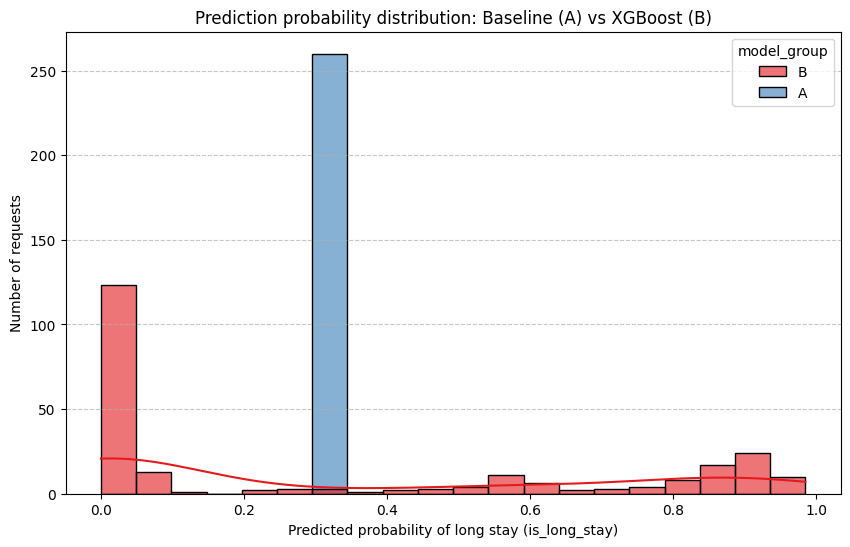

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../results', exist_ok=True)

log_path = '../logs/ab_test_logs.jsonl'
logs = []
with open(log_path, 'r') as f:
    for line in f:
        logs.append(json.loads(line))

df_logs = pd.DataFrame(logs)
print(f"Loaded {len(df_logs)} logs from the microservice.\n")

group_counts = df_logs['model_group'].value_counts()
print("Count of requests per group:")
print(group_counts.to_string())
group_counts.to_csv('../results/group_counts.csv')

print("\nProbability statistics (is_long_stay) by group:")
stats = df_logs.groupby('model_group')['prediction'].describe()[['count', 'mean', 'std', 'min', 'max']]
print(stats)
stats.to_csv('../results/prediction_stats.csv')

plt.figure(figsize=(10, 6))
sns.histplot(data=df_logs, x='prediction', hue='model_group', bins=20, kde=True, palette='Set1', alpha=0.6)
plt.title('Prediction probability distribution: Baseline (A) vs XGBoost (B)')
plt.xlabel('Predicted probability of long stay (is_long_stay)')
plt.ylabel('Number of requests')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../results/prediction_distribution.png', dpi=300, bbox_inches='tight')
plt.show()